In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler


In [ ]:

#Cargamos los CSV procesados
#ruta_clima = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\DataProcesada\clima_procesado_completo.csv"
#ruta_aire = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\DataProcesada\aire_procesado_completo.csv"
#ruta_urgencias = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\DataProcesada\urgencias_procesadas_completo.csv"

#Si se abre código desde VS, se debe incorporar la ruta al leer csv

df_clima = pd.read_csv('clima_procesado_completo.csv')
df_aire = pd.read_csv('aire_procesado_completo.csv')
df_urgencias = pd.read_csv('urgencias_procesadas_completo.csv')

In [ ]:
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RegionNombre          4192 non-null   object 
 1   Semana                4192 non-null   object 
 2   Temp_Mediana_Semanal  4192 non-null   float64
dtypes: float64(1), object(2)
memory usage: 98.4+ KB


In [ ]:
df_aire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RegionNombre          3266 non-null   object 
 1   Semana                3266 non-null   object 
 2   PM25_Mediana_Semanal  3266 non-null   float64
dtypes: float64(1), object(2)
memory usage: 76.7+ KB


In [ ]:
df_urgencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4297 entries, 0 to 4296
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   RegionNombre    4297 non-null   object
 1   Semana          4297 non-null   object
 2   Atenciones_Urg  4297 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 100.8+ KB


In [ ]:
#ANALIZAMOS LOS CRUCES EN LOS NOMBRES DE LAS REGIONES

print(df_clima['RegionNombre'].unique())
print(df_aire['RegionNombre'].unique())
print(df_urgencias['RegionNombre'].unique())


['Región Metropolitana de Santiago' 'Región de Antofagasta'
 'Región de Arica Parinacota' 'Región de Atacama'
 'Región de Aysén del General Carlos Ibañez del Campo'
 'Región de Coquimbo' 'Región de La Araucanía' 'Región de Los Lagos'
 'Región de Los Ríos' 'Región de Magallanes y de la Antártica Chilena'
 'Región de Tarapacá' 'Región de Valparaíso' 'Región de Ñuble'
 'Región del Bíobío' "Región del Libertador Gral. B. O'Higgins"
 'Región del Maule']
['Región Metropolitana de Santiago' 'Región de Antofagasta'
 'Región de Atacama' 'Región de Aysén del General Carlos Ibañez del Campo'
 'Región de Coquimbo' 'Región de La Araucanía' 'Región de Los Lagos'
 'Región de Los Ríos' 'Región de Tarapacá' 'Región de Valparaíso'
 'Región de Ñuble' 'Región del Bíobío'
 "Región del Libertador Gral. B. O'Higgins" 'Región del Maule']
['No Identificado' 'Región Metropolitana de Santiago'
 'Región de Antofagasta' 'Región de Arica Parinacota' 'Región de Atacama'
 'Región de Aysén del General Carlos Ibañez de

In [ ]:
#analizamos cuantos datos de urg corresponden a regiones no identificadas, para tomar una decisión respecto a su análisis
#Calculamos el total de atenciones
total_atenciones = df_urgencias['Atenciones_Urg'].sum()

# Calculamos las atenciones de 'No Identificado'
atenciones_no_id = df_urgencias[df_urgencias['RegionNombre'] == 'No Identificado']['Atenciones_Urg'].sum()

porcentaje_perdida = (atenciones_no_id / total_atenciones) * 100

print(f"Atenciones Totales: {total_atenciones:,.0f}")
print(f"Atenciones 'No Identificado': {atenciones_no_id:,.0f}")
print(f"Porcentaje de datos que perderíamos: {porcentaje_perdida:.2f}%")

Atenciones Totales: 22,337,336
Atenciones 'No Identificado': 531,726
Porcentaje de datos que perderíamos: 2.38%


In [ ]:
df_urgencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4297 entries, 0 to 4296
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   RegionNombre    4297 non-null   object
 1   Semana          4297 non-null   object
 2   Atenciones_Urg  4297 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 100.8+ KB


Debido a que las atenciones de urgencia que no venian con información de región corresponden a un 2.38% del total, lo que se considera una pérdida aceptable y que no interferirá en el desarrollo de los resultados.

In [ ]:
# Eliminamos los datos sin región
df_urgencias = df_urgencias[df_urgencias['RegionNombre'] != 'No Identificado'].copy()

In [ ]:
#Realizamos el merge de todo

# Unimos Urgencias con Clima primero
df_merged1 = pd.merge(df_urgencias, df_clima, on=['Semana', 'RegionNombre'], how='outer')
# Luego unimos el resultado con Aire
df_master = pd.merge(df_merged1, df_aire, on=['Semana', 'RegionNombre'], how='outer')

# Ordenamos cronológicamente
df_master = df_master.sort_values(['RegionNombre', 'Semana']).reset_index(drop=True)

print(f"Dataset unido. Tamaño final: {len(df_master)} filas.")

Dataset unido. Tamaño final: 4192 filas.


In [ ]:
df_master


,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal
0,Región Metropolitana de Santiago,2020-12-29,3483,21.375,13.312500
1,Región Metropolitana de Santiago,2021-01-05,5338,19.300,13.318452
2,Región Metropolitana de Santiago,2021-01-12,4956,19.900,12.934783
3,Región Metropolitana de Santiago,2021-01-19,4563,21.300,17.208333
4,Región Metropolitana de Santiago,2021-01-26,4289,18.900,11.791667
...,...,...,...,...,...
4187,Región del Maule,2025-12-02,9817,21.400,15.708333
4188,Región del Maule,2025-12-09,8509,18.700,14.020833
4189,Región del Maule,2025-12-16,7557,20.600,13.166667
4190,Región del Maule,2025-12-23,7048,21.800,15.541667


In [ ]:
#ANALIZAMOS LA CANTIDAD DE NULOS QUE QUEDARON LUEGO DEL CRUCE
# Conteo absoluto de nulos por columna
nulos_por_columna = df_master.isnull().sum()

porcentaje_nulos = (df_master.isnull().sum() / len(df_master)) * 100

#Crear una tabla de diagnóstico (SOLO PARA VER EL ANALISIS DE MANERA MÁS ORDENADA)
diagnostico = pd.DataFrame({
    'Valores Faltantes': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

print("--- Diagnóstico General de Nulos ---")
print(diagnostico)

# REGIONES CON MAS NULOS
print("\n--- Nulos por Región (Top 5 críticos) ---")
nulos_region = df_master.groupby('RegionNombre').apply(lambda x: x.isnull().sum().sum()).sort_values(ascending=False)
print(nulos_region.head(16))

--- Diagnóstico General de Nulos ---
                      Valores Faltantes  Porcentaje (%)
RegionNombre                          0            0.00
Semana                                0            0.00
Atenciones_Urg                        0            0.00
Temp_Mediana_Semanal                  0            0.00
PM25_Mediana_Semanal                926           22.09

--- Nulos por Región (Top 5 críticos) ---
RegionNombre
Región de Arica Parinacota                             262
Región de Magallanes y de la Antártica Chilena         262
Región de Tarapacá                                     121
Región de Los Ríos                                      34
Región Metropolitana de Santiago                        23
Región de Ñuble                                         21
Región de La Araucanía                                  21
Región de Aysén del General Carlos Ibañez del Campo     21
Región del Libertador Gral. B. O'Higgins                21
Región de Coquimbo                      

/tmp/ipython-input-1782328900.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulos_region = df_master.groupby('RegionNombre').apply(lambda x: x.isnull().sum().sum()).sort_values(ascending=False)


In [ ]:
#Agrupamos por región y contamos los valores no nulos
conteo_data = df_master.groupby('RegionNombre').agg({
    'Semana': 'count',                 # Total de semanas en el periodo
    'Atenciones_Urg': 'count',         # Semanas con datos de salud
    'Temp_Mediana_Semanal': 'count',   # Semanas con datos de temperatura
    'PM25_Mediana_Semanal': 'count'    # Semanas con datos de aire
}).rename(columns={'Semana': 'Total_Semanas_Posibles'})

# Calculamos el porcentaje de completitud para PM2.5 (que es la más crítica que tiene ,+as nulos)
conteo_data['%_Aire_Disponible'] = (conteo_data['PM25_Mediana_Semanal'] / conteo_data['Total_Semanas_Posibles'] * 100).round(2)

#Ordenamos para ver cuáles regiones están más completas
conteo_data = conteo_data.sort_values(by='%_Aire_Disponible', ascending=False)

print("--- Resumen de cantidad de datos por región ---")
print(conteo_data)

--- Resumen de cantidad de datos por región ---
                                                    Total_Semanas_Posibles  \
RegionNombre                                                                 
Región de Antofagasta                                                  262   
Región de Atacama                                                      262   
Región de Los Lagos                                                    262   
Región de Coquimbo                                                     262   
Región del Bíobío                                                      262   
Región del Maule                                                       262   
Región de Valparaíso                                                   262   
Región de Aysén del General Carlos Ibañez del C...                     262   
Región del Libertador Gral. B. O'Higgins                               262   
Región de Ñuble                                                        262   
Región de La Ara

In [ ]:
#debido a que falta data en algunas columnas se utilizará el el promedio de la semana siguiente y anterior al dato faltante

# Definimos tu Top 10 de regiones más contaminadas
top_10_regiones = [
    "Región de Aysén del General Carlos Ibañez del Campo",
    "Región Metropolitana de Santiago",
    "Región del Libertador Gral. B. O'Higgins",
    "Región de Los Lagos",
    "Región de Valparaíso",
    "Región del Maule",
    "Región de La Araucanía",
    "Región de Ñuble",
    "Región del Bíobío",
    "Región de Los Ríos"
]

# Filtramos el DataFrame Maestro
df_top10 = df_master[df_master['RegionNombre'].isin(top_10_regiones)].copy()

# Rellenar con el promedio de la semana anterior y posterior, usamos 'interpolate'
cols_a_completar = ['Atenciones_Urg', 'Temp_Mediana_Semanal', 'PM25_Mediana_Semanal']

for col in cols_a_completar:
    # Agrupamos por región para que el promedio sea local y no mezcle zonas
    df_top10[col] = df_top10.groupby('RegionNombre')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

#
print("Nulos restantes en el Top 10:")
print(df_top10[cols_a_completar].isnull().sum())

Nulos restantes en el Top 10:
Atenciones_Urg          0
Temp_Mediana_Semanal    0
PM25_Mediana_Semanal    0
dtype: int64


In [ ]:
df_top10

,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal
0,Región Metropolitana de Santiago,2020-12-29,3483,21.375,13.312500
1,Región Metropolitana de Santiago,2021-01-05,5338,19.300,13.318452
2,Región Metropolitana de Santiago,2021-01-12,4956,19.900,12.934783
3,Región Metropolitana de Santiago,2021-01-19,4563,21.300,17.208333
4,Región Metropolitana de Santiago,2021-01-26,4289,18.900,11.791667
...,...,...,...,...,...
4187,Región del Maule,2025-12-02,9817,21.400,15.708333
4188,Región del Maule,2025-12-09,8509,18.700,14.020833
4189,Región del Maule,2025-12-16,7557,20.600,13.166667
4190,Región del Maule,2025-12-23,7048,21.800,15.541667


In [ ]:
nombres_cortos = {
    "Región Metropolitana de Santiago": "RM",
    "Región de Aysén del General Carlos Ibañez del Campo": "Aysén",
    "Región de La Araucanía": "Araucanía",
    "Región de Los Lagos": "Los Lagos",
    "Región de Los Ríos": "Los Ríos",
    "Región de Valparaíso": "Valparaíso",
    "Región de Ñuble": "Ñuble",
    "Región del Bíobío": "Bío-Bío",
    "Región del Libertador Gral. B. O'Higgins": "O'Higgins",
    "Región del Maule": "Maule"
}

df_top10['Semana'] = pd.to_datetime(df_top10['Semana'])

df_top10['Mes'] = df_top10['Semana'].dt.month
df_top10['Region_Corta'] = df_top10['RegionNombre'].map(nombres_cortos)

In [ ]:
#Obtenemos las estadisticas descriptivas a nivel nacional
resumen_nacional=df_top10.describe()
print('Estadísticas descriptivas a nivel nacional\n',resumen_nacional)

Estadísticas descriptivas a nivel nacional
                               Semana  Atenciones_Urg  Temp_Mediana_Semanal  \
count                           2620     2620.000000           2620.000000   
mean   2023-06-30 12:00:00.000000256     7231.763740             12.589532   
min              2020-12-29 00:00:00       63.000000             -3.600000   
25%              2022-03-29 00:00:00     1850.750000              9.250000   
50%              2023-06-30 12:00:00     4524.000000             12.250000   
75%              2024-10-01 00:00:00     8971.500000             15.950000   
max              2025-12-30 00:00:00    68367.000000             25.750000   
std                              NaN     8789.688366              4.636935   

       PM25_Mediana_Semanal          Mes  
count           2620.000000  2620.000000  
mean              27.943730     6.553435  
min                1.340909     1.000000  
25%               16.479038     4.000000  
50%               21.971691     7.0000

In [ ]:
#Obtenemos las estadisticas descriptivas a nivel regional

resumen_regional=df_top10.groupby('RegionNombre').describe()
print('Estadísticas descriptivas Top 10 regiones\n',resumen_regional)

Estadísticas descriptivas Top 10 regiones
                                                    Semana  \
                                                    count   
RegionNombre                                                
Región Metropolitana de Santiago                      262   
Región de Aysén del General Carlos Ibañez del C...    262   
Región de La Araucanía                                262   
Región de Los Lagos                                   262   
Región de Los Ríos                                    262   
Región de Valparaíso                                  262   
Región de Ñuble                                       262   
Región del Bíobío                                     262   
Región del Libertador Gral. B. O'Higgins              262   
Región del Maule                                      262   

                                                                         \
                                                                   mean   
RegionNombre 

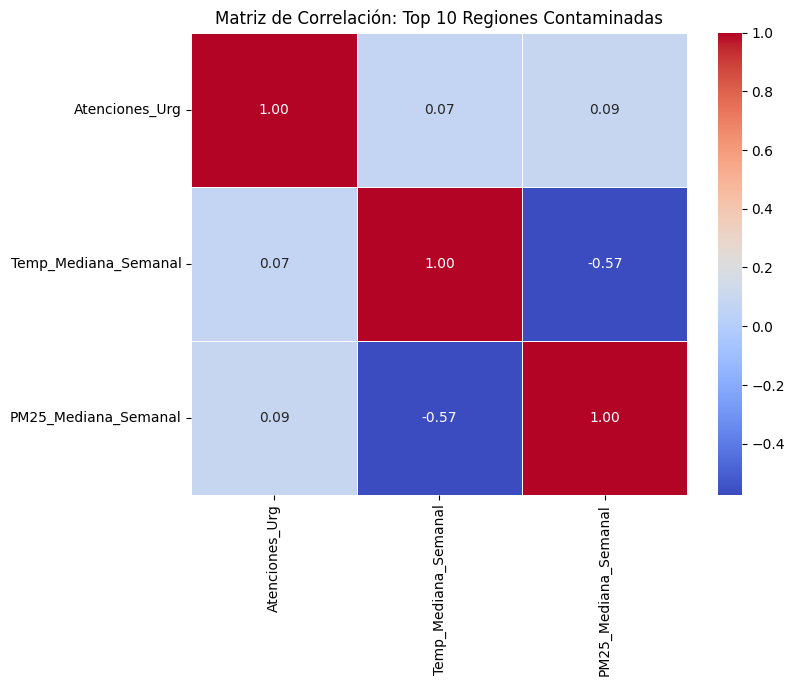

In [ ]:
# Calculamos la correlación
corr_matrix = df_top10[cols_a_completar].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación: Top 10 Regiones Contaminadas")
plt.show()

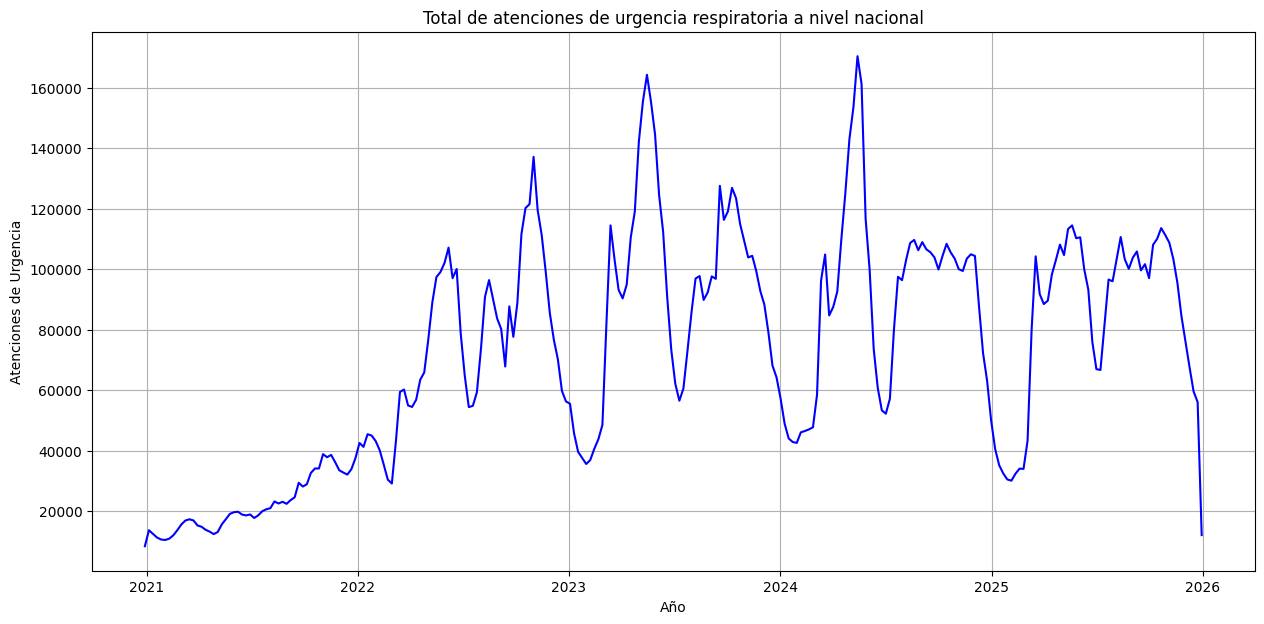

In [ ]:
#Tendencias globales urgencias

df_top10['Semana']=pd.to_datetime(df_top10['Semana'])
data_agrupada = df_top10.groupby('Semana')['Atenciones_Urg'].sum()

# Ahora graficamos indicando el índice (fechas) y los valores (atenciones)
plt.figure(figsize=(15, 7))
plt.plot(data_agrupada.index, data_agrupada.values, color='blue')
plt.xlabel('Año')
plt.ylabel('Atenciones de Urgencia')
plt.title('Total de atenciones de urgencia respiratoria a nivel nacional')
plt.grid(True)
plt.show()

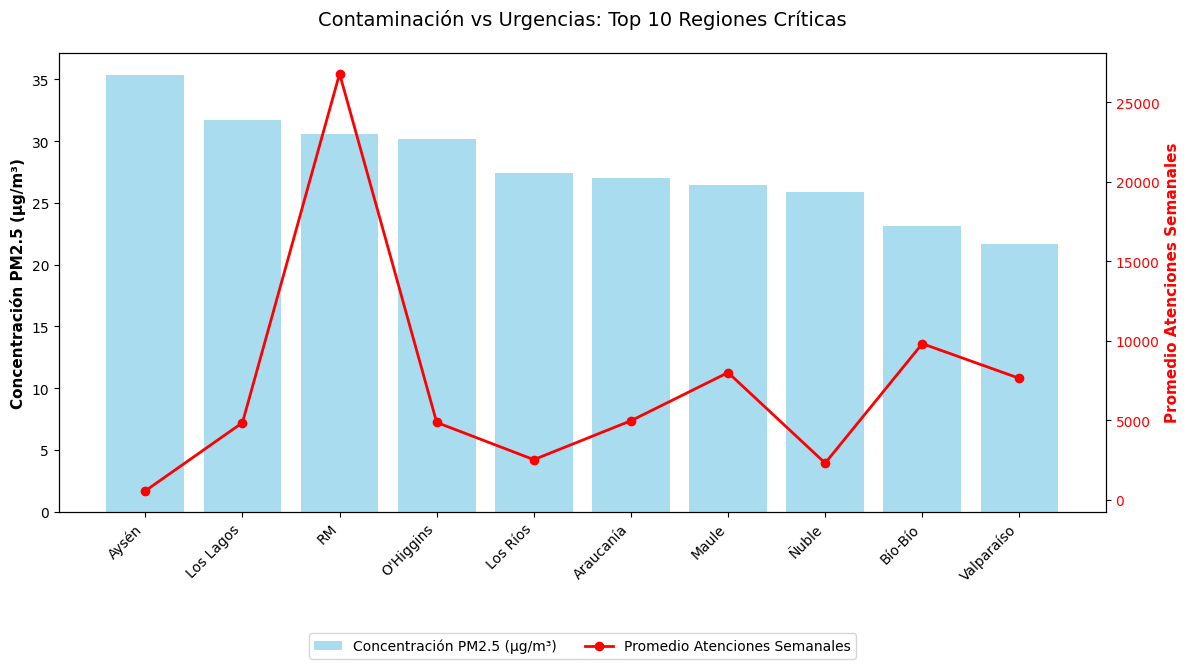

In [ ]:
# Resumen por región
eda_region = df_top10.groupby('RegionNombre')[cols_a_completar].mean().sort_values(by='PM25_Mediana_Semanal', ascending=False)

# Diccionario de nombres cortos para el gráfico
nombres_cortos = {
    "Región de Aysén del General Carlos Ibañez del Campo": "Aysén",
    "Región Metropolitana de Santiago": "RM",
    "Región del Libertador Gral. B. O'Higgins": "O'Higgins",
    "Región de Los Lagos": "Los Lagos",
    "Región de Valparaíso": "Valparaíso",
    "Región del Maule": "Maule",
    "Región de La Araucanía": "Araucanía",
    "Región de Ñuble": "Ñuble",
    "Región del Bíobío": "Bío-Bío",
    "Región de Los Ríos": "Los Ríos"
}

# Aplicamos los nombres cortos solo para el eje X del gráfico
nombres_eje_x = [nombres_cortos.get(reg, reg) for reg in eda_region.index]

fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras para Contaminación
ax1.bar(nombres_eje_x, eda_region['PM25_Mediana_Semanal'], color='skyblue', alpha=0.7, label='Concentración PM2.5 (µg/m³)')
ax1.set_ylabel('Concentración PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
# Rotación a 45 grados para mejor lectura
plt.xticks(rotation=45, ha='right')

#Línea para Urgencias
ax2 = ax1.twinx()
ax2.plot(nombres_eje_x, eda_region['Atenciones_Urg'], color='red', marker='o', linewidth=2, label='Promedio Atenciones Semanales')
ax2.set_ylabel('Promedio Atenciones Semanales', fontsize=11, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Contaminación vs Urgencias: Top 10 Regiones Críticas", fontsize=14, pad=20)

# Leyenda unificada en la parte inferior
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

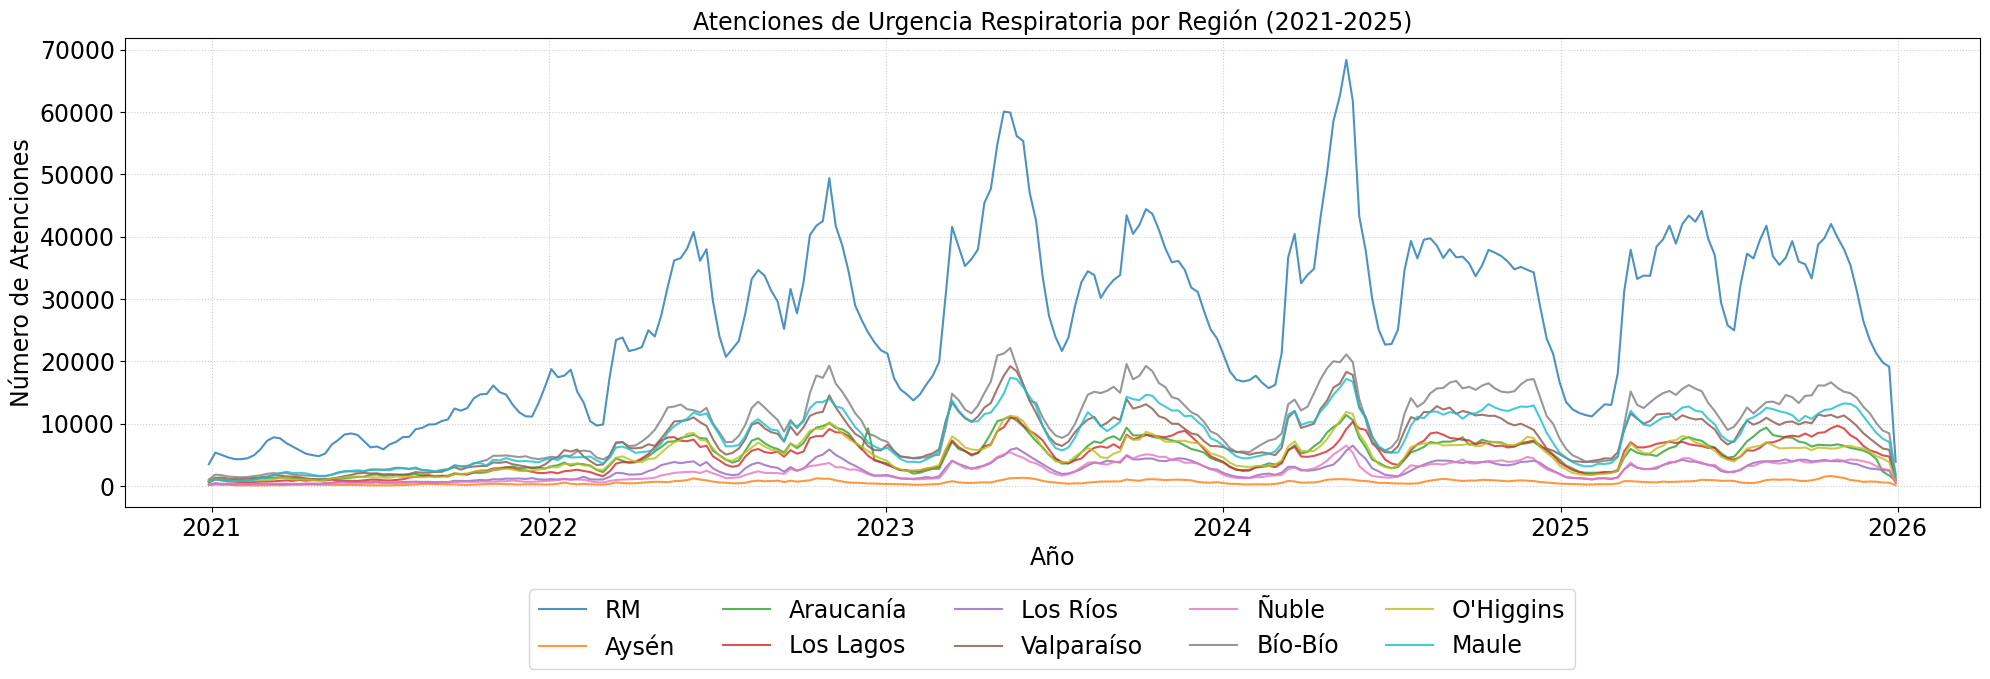

In [ ]:
import matplotlib.dates as mdates
#Análisis temporal por región

plt.figure(figsize=(20, 7))
ax = plt.gca()

#Garficamos por región
for region in df_top10['Region_Corta'].unique():
    subset = df_top10[df_top10['Region_Corta'] == region]
    subset = subset.sort_values('Semana')
    plt.plot(subset['Semana'], subset['Atenciones_Urg'], label=region, alpha=0.8)
# Marcamos solo el inicio de cada año
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Atenciones de Urgencia Respiratoria por Región (2021-2025)', fontsize=17)
plt.xlabel('Año',fontsize=17)
plt.ylabel('Número de Atenciones',fontsize=17)
plt.grid(True, linestyle=':', alpha=0.6)

# leyende
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', fontsize='17', ncol=5)

plt.xticks(fontsize=17)
plt.yticks(fontsize=17)

plt.tight_layout()
plt.show()

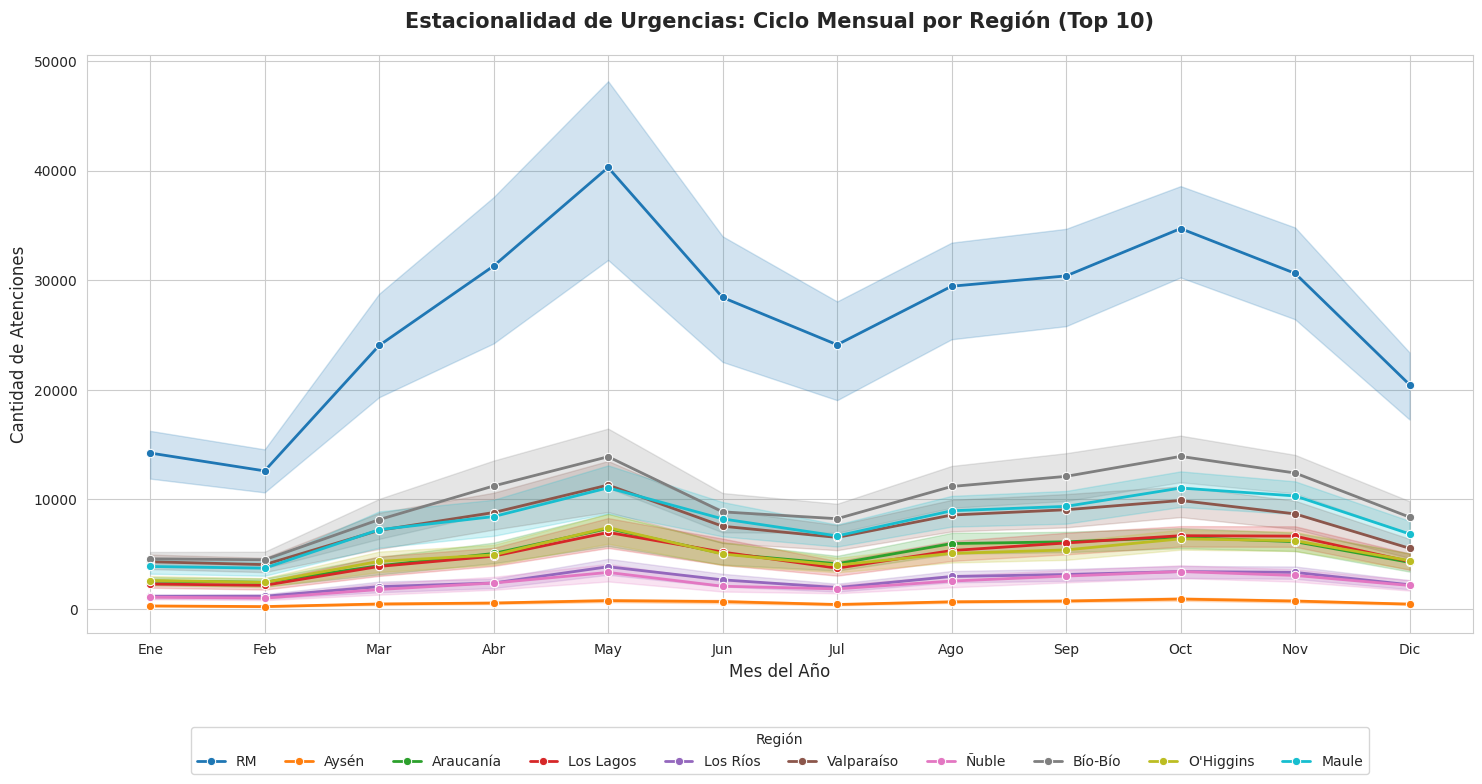

In [ ]:
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")


ax = sns.lineplot(data=df_top10, x='Mes', y='Atenciones_Urg',
                  hue='Region_Corta', marker="o", linewidth=2, palette="tab10")

plt.title("Estacionalidad de Urgencias: Ciclo Mensual por Región (Top 10)", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Mes del Año", fontsize=12)
plt.ylabel("Cantidad de Atenciones", fontsize=12)

plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.legend(title="Región", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=10, frameon=True)


plt.tight_layout()
plt.show()

/tmp/ipython-input-2421881630.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='RegionNombre', y='Atenciones_Urg', palette='Set3')


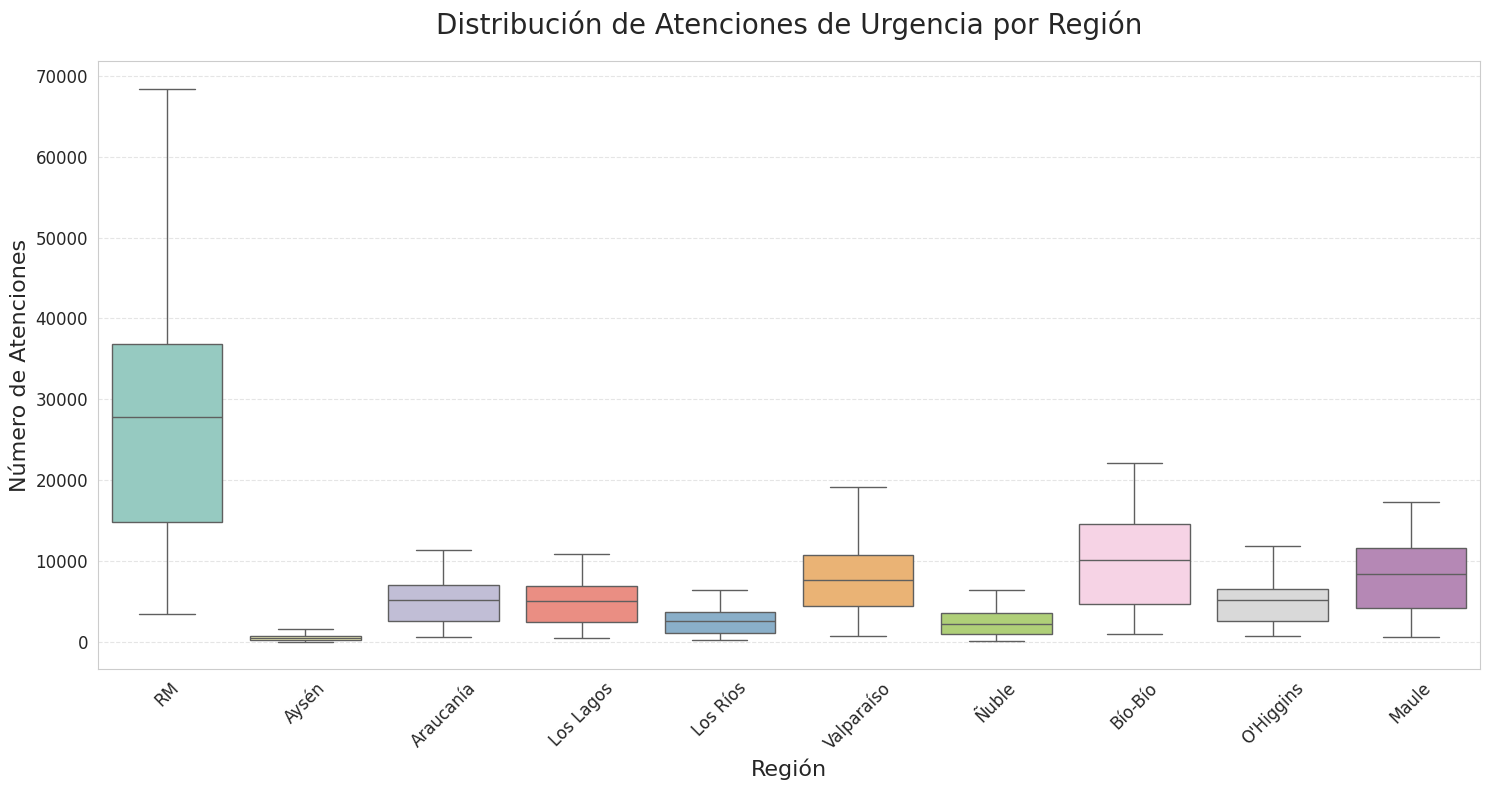

In [ ]:
# Comparativa epidemiolóigica

#Aplicación de nombres cortos a las regiones
df_top10['RegionNombre'] = df_top10['RegionNombre'].map(lambda x: nombres_cortos.get(x, x))

plt.figure(figsize=(15, 8))

# Eje X regiones
# Eje Y atenciones
sns.boxplot(data=df_top10, x='RegionNombre', y='Atenciones_Urg', palette='Set3')

plt.title('Distribución de Atenciones de Urgencia por Región', fontsize=20, pad=20)
plt.xlabel('Región', fontsize=16)
plt.ylabel('Número de Atenciones', fontsize=16)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

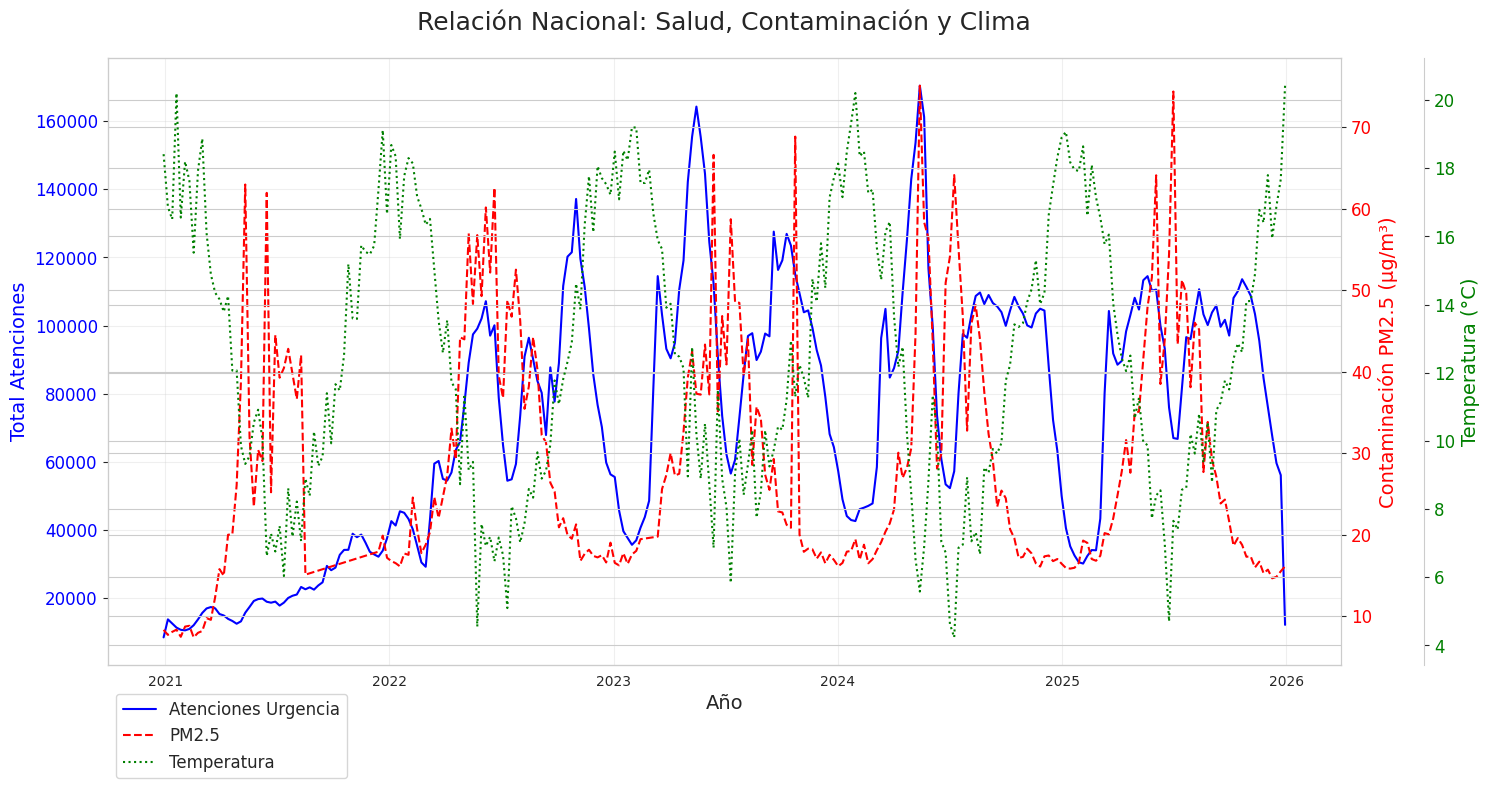

In [ ]:
#2DO GRÁFICO EPIDEMIOLÓGICO

df_nacional = df_top10.groupby('Semana').agg({
    'Atenciones_Urg': 'sum',           # Sumamos las atenciones totales país
    'PM25_Mediana_Semanal': 'mean',    # Promediamos la contaminación
    'Temp_Mediana_Semanal': 'mean'     # Promediamos la temperatura
}).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 8))

# Urg. eje izq
line1, = ax1.plot(df_nacional['Semana'], df_nacional['Atenciones_Urg'],
                  color='blue', linewidth=1.5, label='Atenciones Urgencia')
ax1.set_xlabel('Año', fontsize=14)
ax1.set_ylabel('Total Atenciones', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)

# pm2.5 eje der
ax2 = ax1.twinx() # Crea un eje que comparte el mismo eje X
line2, = ax2.plot(df_nacional['Semana'], df_nacional['PM25_Mediana_Semanal'],
                  color='red', linewidth=1.5, linestyle='--', label='PM2.5')
ax2.set_ylabel('Contaminación PM2.5 (µg/m³)', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red', labelsize=12)

# temp
ax3 = ax1.twinx()

ax3.spines['right'].set_position(('outward', 60))
line3, = ax3.plot(df_nacional['Semana'], df_nacional['Temp_Mediana_Semanal'],
                  color='green', linewidth=1.5, linestyle=':', label='Temperatura')
ax3.set_ylabel('Temperatura (°C)', color='green', fontsize=14)
ax3.tick_params(axis='y', labelcolor='green', labelsize=12)


plt.title('Relación Nacional: Salud, Contaminación y Clima', fontsize=18, pad=20)
ax1.grid(True, alpha=0.3)

# Unir todas las leyendas en una sola caja
lines = [line1, line2, line3]
ax1.legend(lines, [l.get_label() for l in lines],bbox_to_anchor=(0.0, -0.2) ,loc='lower left', fontsize=12)

plt.tight_layout()
plt.show()

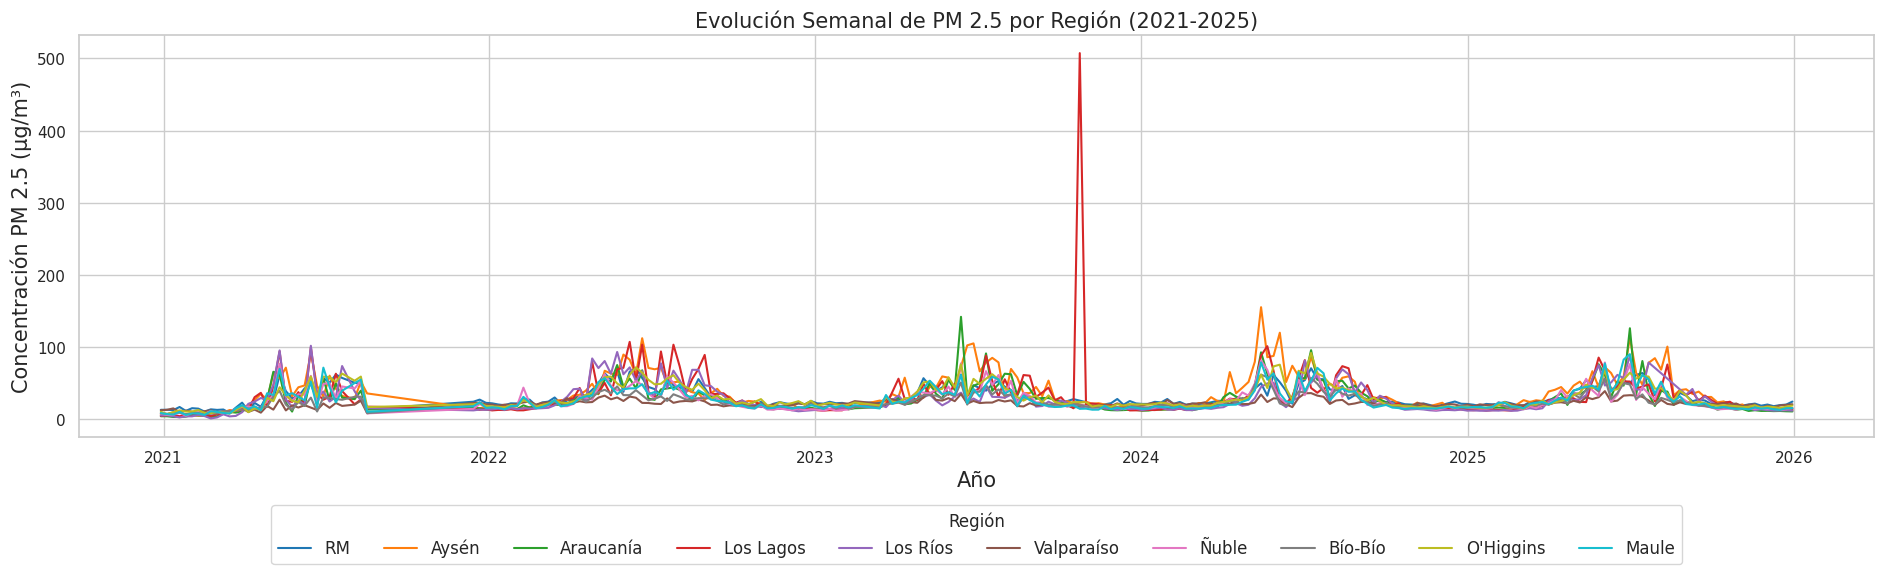

In [ ]:
#Análissi comportamiento PM 2.5 a nivel regional
plt.figure(figsize=(19, 6))
sns.set_theme(style="whitegrid")

plot = sns.lineplot(
    data=df_top10,
    x='Semana',
    y='PM25_Mediana_Semanal',
    hue='Region_Corta',
    palette='tab10',
    linewidth=1.5
)

plt.title('Evolución Semanal de PM 2.5 por Región (2021-2025)', fontsize=15)
plt.xlabel('Año', fontsize=15)
plt.ylabel('Concentración PM 2.5 (µg/m³)', fontsize=15)
plt.legend(title='Región', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=10, fontsize=12)
plt.tight_layout()

plt.show()

In [ ]:
#Realizmos un análisis a nivel regional, pero observamos como se comporta por estación del año

#Creamos la columna estación del año para poder graficar mejor la data

def estacion_del_anio(fecha):
    mes = fecha.month
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    else:
        return 'Primavera'

df_top10_cop=df_top10.copy()
df_top10_cop['estacion'] = df_top10_cop['Semana'].apply(estacion_del_anio)

In [ ]:
df_top10_cop

,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal,Mes,Region_Corta,estacion
0,RM,2020-12-29,3483,21.375,13.312500,12,RM,Verano
1,RM,2021-01-05,5338,19.300,13.318452,1,RM,Verano
2,RM,2021-01-12,4956,19.900,12.934783,1,RM,Verano
3,RM,2021-01-19,4563,21.300,17.208333,1,RM,Verano
4,RM,2021-01-26,4289,18.900,11.791667,1,RM,Verano
...,...,...,...,...,...,...,...,...
4187,Maule,2025-12-02,9817,21.400,15.708333,12,Maule,Verano
4188,Maule,2025-12-09,8509,18.700,14.020833,12,Maule,Verano
4189,Maule,2025-12-16,7557,20.600,13.166667,12,Maule,Verano
4190,Maule,2025-12-23,7048,21.800,15.541667,12,Maule,Verano


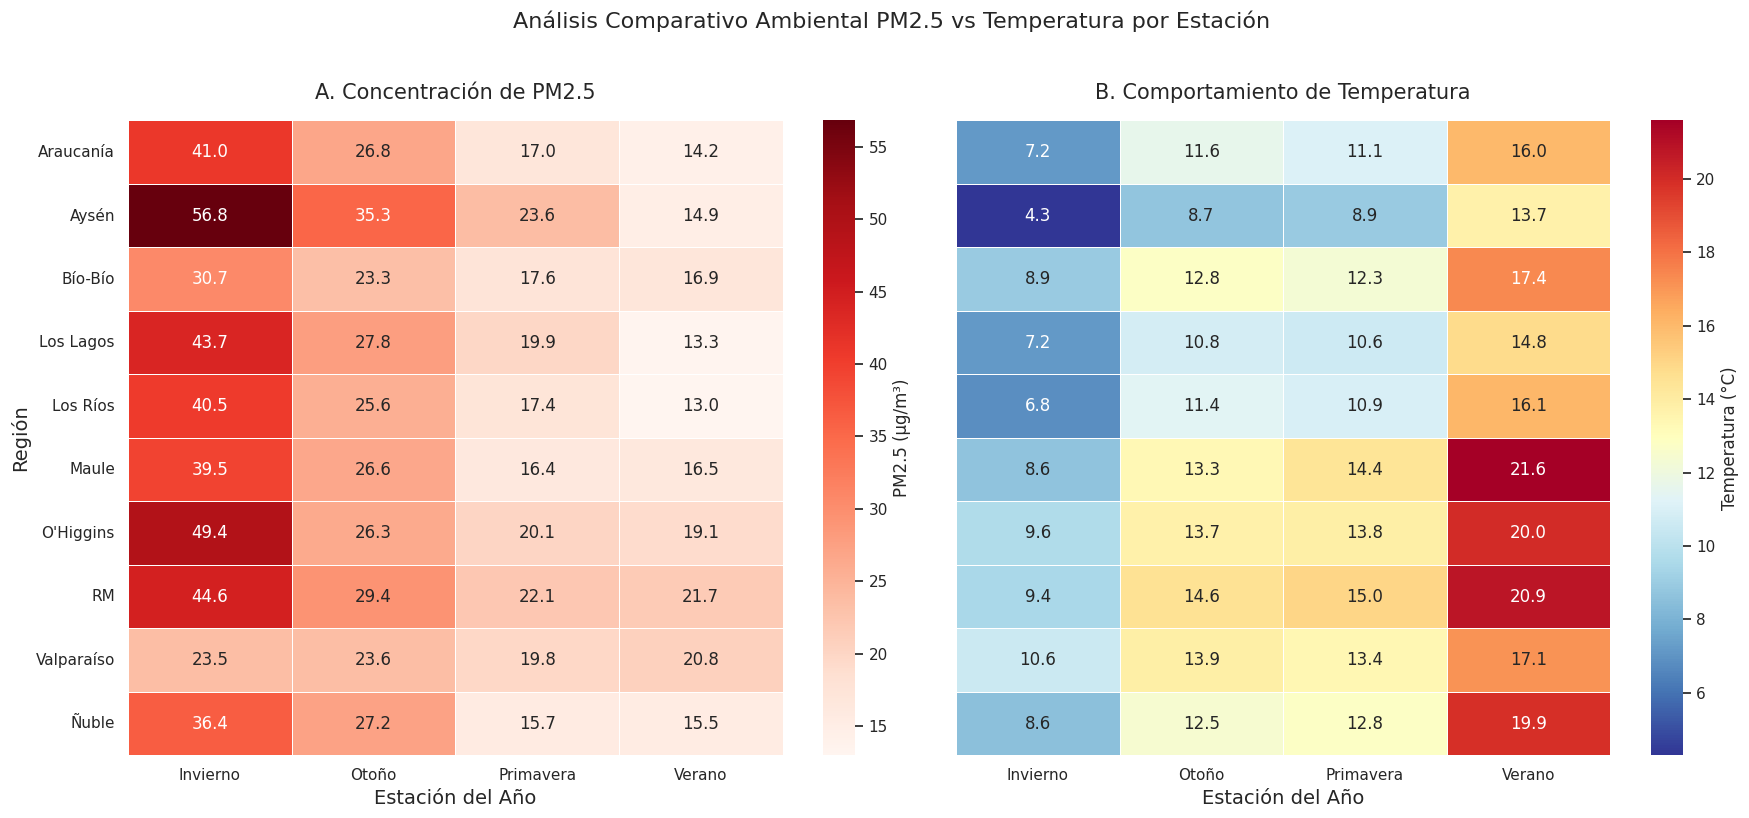

In [ ]:
# Realizamos una comparativa por región y por estación del año, del clima y la concentración de PM 25.
pm25_heat = (
    df_top10_cop
    .groupby(['Region_Corta', 'estacion'])['PM25_Mediana_Semanal']
    .median()
    .unstack() # Heatmap de PM2.5
)

temp_heat = (
    df_top10_cop
    .groupby(['Region_Corta', 'estacion'])['Temp_Mediana_Semanal']
    .median()
    .unstack() # Heatmap de temperatura
)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
sns.set_theme(style="white")

# Heatmap 1 PM2.5
sns.heatmap(
    pm25_heat,
    ax=axes[0],
    cmap='Reds',
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cbar_kws={'label': 'PM2.5 (µg/m³)'}
)
axes[0].set_title('A. Concentración de PM2.5', fontsize=15, pad=15)
axes[0].set_xlabel('Estación del Año', fontsize=14)
axes[0].set_ylabel('Región', fontsize=14)

# Heatmap 2 t°
sns.heatmap(
    temp_heat,
    ax=axes[1],
    cmap='RdYlBu_r',
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cbar_kws={'label': 'Temperatura (°C)'}
)
axes[1].set_title('B. Comportamiento de Temperatura', fontsize=15, pad=15)
axes[1].set_xlabel('Estación del Año', fontsize=14)
axes[1].set_ylabel('')

plt.suptitle('Análisis Comparativo Ambiental PM2.5 vs Temperatura por Estación', fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

In [ ]:
df_top10_cop

,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal,Mes,Region_Corta,estacion
0,RM,2020-12-29,3483,21.375,13.312500,12,RM,Verano
1,RM,2021-01-05,5338,19.300,13.318452,1,RM,Verano
2,RM,2021-01-12,4956,19.900,12.934783,1,RM,Verano
3,RM,2021-01-19,4563,21.300,17.208333,1,RM,Verano
4,RM,2021-01-26,4289,18.900,11.791667,1,RM,Verano
...,...,...,...,...,...,...,...,...
4187,Maule,2025-12-02,9817,21.400,15.708333,12,Maule,Verano
4188,Maule,2025-12-09,8509,18.700,14.020833,12,Maule,Verano
4189,Maule,2025-12-16,7557,20.600,13.166667,12,Maule,Verano
4190,Maule,2025-12-23,7048,21.800,15.541667,12,Maule,Verano


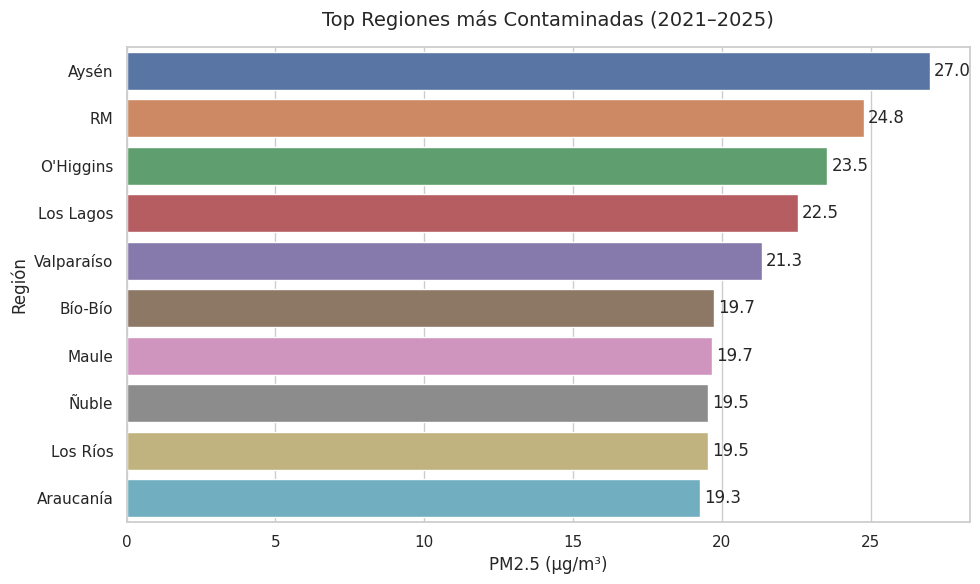

In [ ]:
#Graficamos el top de regiones contaminadas

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

data_plot = (
    df_top10_cop.groupby('Region_Corta')['PM25_Mediana_Semanal']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
bar_plot = sns.barplot(
    data=data_plot,
    x='PM25_Mediana_Semanal',
    y='Region_Corta',
    hue='Region_Corta',
    legend=False)

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.1f', padding=3)

plt.title('Top Regiones más Contaminadas (2021–2025)', fontsize=14, pad=15)
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Región')
plt.tight_layout()

plt.show()

In [ ]:
#ANALIZAMOS LA CANTIDAD DE NULOS QUE QUEDARON LUEGO DEL CRUCE
# Conteo absoluto de nulos por columna
nulos_por_columna = df_master.isnull().sum()

porcentaje_nulos = (df_master.isnull().sum() / len(df_master)) * 100

#Crear una tabla de diagnóstico (SOLO PARA VER EL ANALISIS DE MANERA MÁS ORDENADA)
diagnostico = pd.DataFrame({
    'Valores Faltantes': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

print("--- Diagnóstico General de Nulos ---")
print(diagnostico)

# REGIONES CON MAS NULOS
print("\n--- Nulos por Región (Top 5 críticos) ---")
nulos_region = df_master.groupby('RegionNombre').apply(lambda x: x.isnull().sum().sum()).sort_values(ascending=False)
print(nulos_region.head(10))

--- Diagnóstico General de Nulos ---
                      Valores Faltantes  Porcentaje (%)
RegionNombre                          0            0.00
Semana                                0            0.00
Atenciones_Urg                        0            0.00
Temp_Mediana_Semanal                  0            0.00
PM25_Mediana_Semanal                926           22.09

--- Nulos por Región (Top 5 críticos) ---
RegionNombre
Región de Arica Parinacota                             262
Región de Magallanes y de la Antártica Chilena         262
Región de Tarapacá                                     121
Región de Los Ríos                                      34
Región Metropolitana de Santiago                        23
Región de Ñuble                                         21
Región de La Araucanía                                  21
Región de Aysén del General Carlos Ibañez del Campo     21
Región del Libertador Gral. B. O'Higgins                21
Región de Coquimbo                      

/tmp/ipython-input-3947414532.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulos_region = df_master.groupby('RegionNombre').apply(lambda x: x.isnull().sum().sum()).sort_values(ascending=False)


In [ ]:
#Realizamos e análisis de los Lags o "rezagos", que tanto impactan o no las semanas anteriores de contaminación en las urgencias

# Creamos los rezagos (lags) por cada región para no mezclar datos de distintas zonas
df_top10['PM25_Lag1'] = df_top10.groupby('RegionNombre')['PM25_Mediana_Semanal'].shift(1)
df_top10['PM25_Lag2'] = df_top10.groupby('RegionNombre')['PM25_Mediana_Semanal'].shift(2)

# Como al desplazar los datos quedan algunos nulos al principio, los eliminamos
df_lag = df_top10.dropna(subset=['PM25_Lag1', 'PM25_Lag2'])

# Ahora calculamos la correlación para ver cuál influye más
correlaciones_lag = df_lag[['Atenciones_Urg', 'PM25_Mediana_Semanal', 'PM25_Lag1', 'PM25_Lag2']].corr()

print("Comparación de Correlaciones con las Urgencias:")
print(correlaciones_lag['Atenciones_Urg'])

Comparación de Correlaciones con las Urgencias:
Atenciones_Urg          1.000000
PM25_Mediana_Semanal    0.081822
PM25_Lag1               0.084202
PM25_Lag2               0.082849
Name: Atenciones_Urg, dtype: float64


la contaminación de la semana pasada tiene una relación más fuerte con las urgencias de esta semana que el aire que se está respirando hoy mismo. Esto confirma científicamente que el efecto de la contaminación en la población no es instantáneo, sino que tiene un periodo de incubación o respuesta biológica de aproximadamente 7 días. OJO Es la representación escrita de la matriz de correlación

In [ ]:
#Realizamos análisis territorial (matriz de correlación) por región

# Lista para análisis territorial
analisis_territorial = []

for region in df_top10['RegionNombre'].unique():
    df_reg = df_top10[df_top10['RegionNombre'] == region]

    sens_aire = df_reg['Atenciones_Urg'].corr(df_reg['PM25_Lag1'])

    sens_frio = df_reg['Atenciones_Urg'].corr(df_reg['Temp_Mediana_Semanal'])

    analisis_territorial.append({
        'Region': region,
        'Impacto_Aire (r)': sens_aire,
        'Impacto_Frio (r)': sens_frio
    })

# Creamos df para analizar impacto de las variables ambientales con las urgencias
df_ranking = pd.DataFrame(analisis_territorial).sort_values(by='Impacto_Aire (r)', ascending=False)
#df_ranking['Region'] = df_ranking['Region'].map(nombres_cortos)

print("Ranking de Impacto: Aire vs. Frío")
print(df_ranking[['Region', 'Impacto_Aire (r)', 'Impacto_Frio (r)']].to_string(index=False))

Ranking de Impacto: Aire vs. Frío
    Region  Impacto_Aire (r)  Impacto_Frio (r)
Valparaíso          0.522023         -0.272586
   Bío-Bío          0.373251         -0.362498
 Araucanía          0.311040         -0.365174
        RM          0.307835         -0.329378
     Aysén          0.277182         -0.337031
  Los Ríos          0.266442         -0.328371
 O'Higgins          0.253578         -0.279422
 Los Lagos          0.231593         -0.307405
     Maule          0.212356         -0.274204
     Ñuble          0.197013         -0.273499


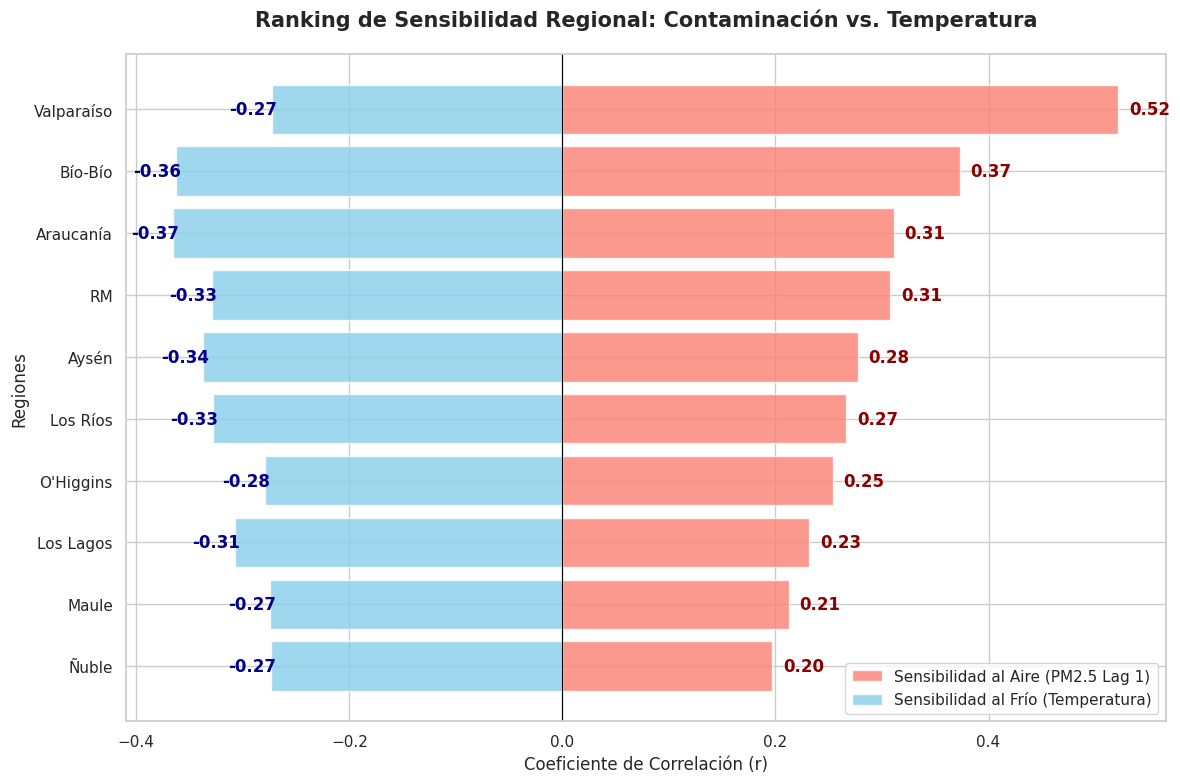

In [ ]:
#graficamos resultados anteriores

df_ranking = df_ranking.sort_values(by='Impacto_Aire (r)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bars_aire = ax.barh(df_ranking['Region'], df_ranking['Impacto_Aire (r)'],
                    color='salmon', label='Sensibilidad al Aire (PM2.5 Lag 1)', alpha=0.8)

bars_frio = ax.barh(df_ranking['Region'], df_ranking['Impacto_Frio (r)'],
                    color='skyblue', label='Sensibilidad al Frío (Temperatura)', alpha=0.8)


ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ranking de Sensibilidad Regional: Contaminación vs. Temperatura', fontsize=15, pad=20, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlación (r)', fontsize=12)
ax.set_ylabel('Regiones', fontsize=12)
ax.legend(loc='lower right', frameon=True)

for i, bar in enumerate(bars_aire):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{df_ranking["Impacto_Aire (r)"].iloc[i]:.2f}', va='center', color='darkred', fontweight='bold')

for i, bar in enumerate(bars_frio):
    ax.text(bar.get_width() - 0.04, bar.get_y() + bar.get_height()/2,
            f'{df_ranking["Impacto_Frio (r)"].iloc[i]:.2f}', va='center', color='darkblue', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_top10.isnull().sum()

,0
RegionNombre,0
Semana,0
Atenciones_Urg,0
Temp_Mediana_Semanal,0
PM25_Mediana_Semanal,0
Mes,0
Region_Corta,0
PM25_Lag1,10
PM25_Lag2,20


In [ ]:
cols_a_completar = ['PM25_Lag1','PM25_Lag2']

for col in cols_a_completar:
    # Agrupamos por región para que el promedio sea local y no mezcle zonas
    df_top10[col] = df_top10.groupby('RegionNombre')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

#
print("Nulos restantes en el Top 10:")
print(df_top10[cols_a_completar].isnull().sum())

Nulos restantes en el Top 10:
PM25_Lag1    0
PM25_Lag2    0
dtype: int64


In [ ]:
df_top10
df_top10.to_csv("df_top10.csv", index=False)

In [ ]:
df_top10['RegionNombre'].unique()

array(['RM', 'Aysén', 'Araucanía', 'Los Lagos', 'Los Ríos', 'Valparaíso',
       'Ñuble', 'Bío-Bío', "O'Higgins", 'Maule'], dtype=object)

In [ ]:
df_top10[df_top10['RegionNombre'] == 'Valparaíso']

,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal,Mes,Region_Corta,PM25_Lag1,PM25_Lag2
2882,Valparaíso,2020-12-29,776,16.75,12.705611,12,Valparaíso,12.705611,12.705611
2883,Valparaíso,2021-01-05,1293,16.20,13.337619,1,Valparaíso,12.705611,12.705611
2884,Valparaíso,2021-01-12,1333,15.70,15.272000,1,Valparaíso,13.337619,12.705611
2885,Valparaíso,2021-01-19,1146,16.90,10.045000,1,Valparaíso,15.272000,13.337619
2886,Valparaíso,2021-01-26,1137,18.40,12.171818,1,Valparaíso,10.045000,15.272000
...,...,...,...,...,...,...,...,...,...
3139,Valparaíso,2025-12-02,7587,17.55,18.958333,12,Valparaíso,16.000000,20.687500
3140,Valparaíso,2025-12-09,6796,17.00,16.958333,12,Valparaíso,18.958333,16.000000
3141,Valparaíso,2025-12-16,5996,17.30,19.333333,12,Valparaíso,16.958333,18.958333
3142,Valparaíso,2025-12-23,5787,17.80,20.166667,12,Valparaíso,19.333333,16.958333


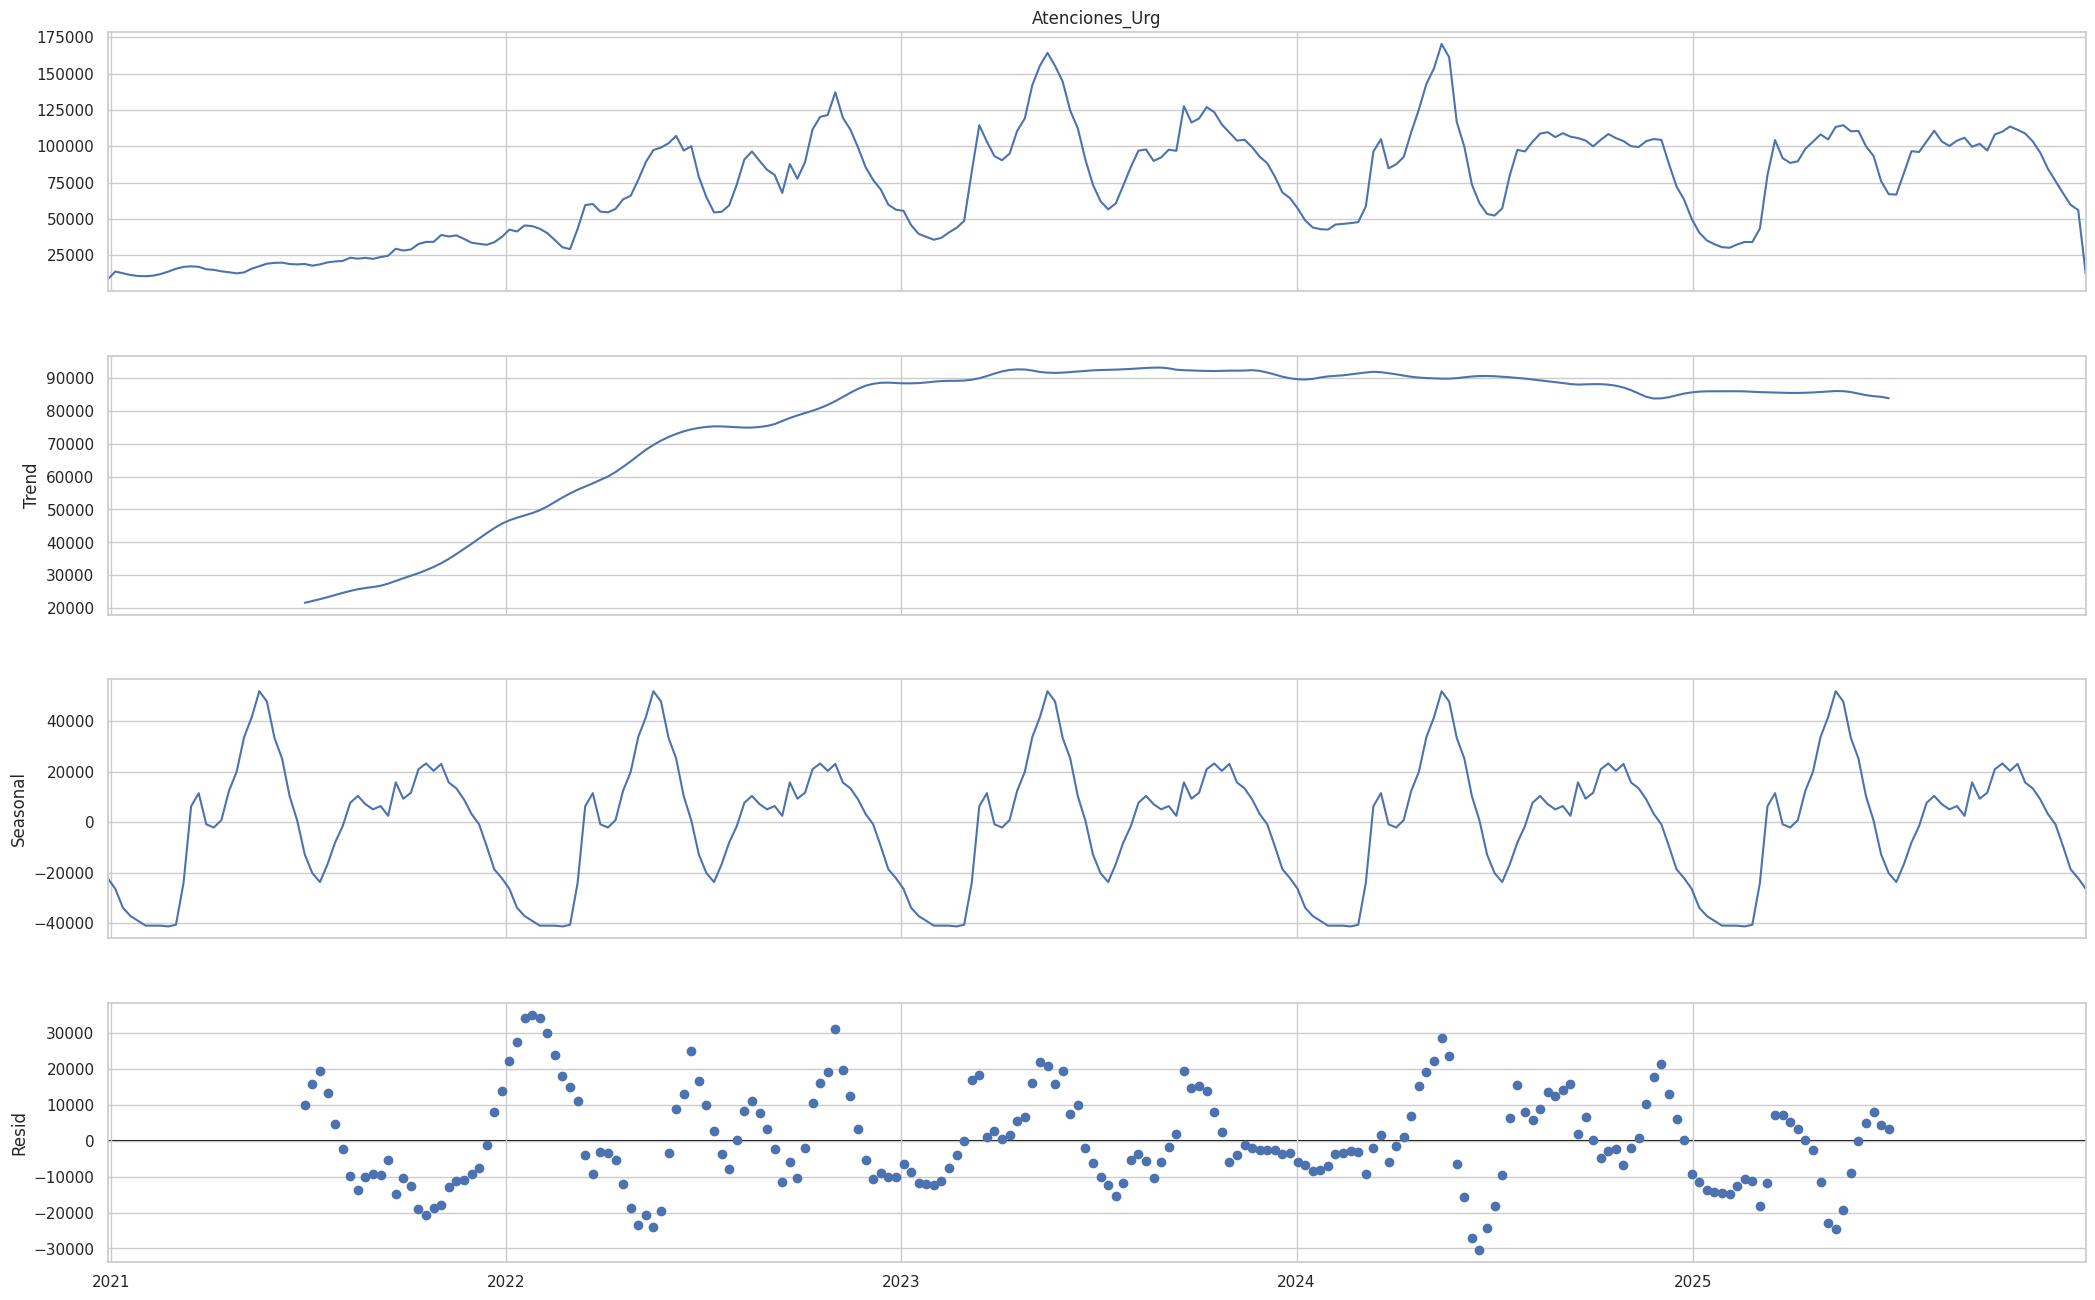

In [ ]:
#ANALISIS DE COMPONENTES DE LA SERIE DE TIEMPO

from statsmodels.tsa.seasonal import seasonal_decompose

serie = df_top10.groupby('Semana')['Atenciones_Urg'].sum()

result = seasonal_decompose(serie, model='additive')


# Graficamos la descomposición con tamaño grande
fig = result.plot()
fig.set_size_inches(25, 15)  # ancho x alto
plt.show()

In [ ]:
#ANALISIS ESTACIONARIEDAD
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

#Aplicar la Prueba de Dickey-Fuller Aumentada (ADF)
print("\n--- Prueba de Dickey-Fuller Aumentada (ADF) ---")
adf_result = adfuller(serie, autolag='AIC')

# Formateamos y mostramos resultados
print(f'Estadístico ADF: {adf_result[0]:.4f}')
print(f'P-valor: {adf_result[1]:.4f}')
print('Valores Críticos (Niveles de Confianza):')
for key, value in adf_result[4].items():
    print(f'  {key}: {value:.4f}')


if adf_result[1] <= 0.05:
    print("\nConclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo es estacionaria.")
else:
    print("\nConclusión: El P-valor es > 0.05. NO se rechaza H0, la serie de tiempo NO es estacionaria. Se requerirá diferenciación.")


--- Prueba de Dickey-Fuller Aumentada (ADF) ---
Estadístico ADF: -3.5169
P-valor: 0.0076
Valores Críticos (Niveles de Confianza):
  1%: -3.4558
  5%: -2.8727
  10%: -2.5727

Conclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo es estacionaria.


In [ ]:
# Aplicar el Test KPSS. Usamos 'c' (constante) para probar la estacionariedad alrededor de la media
print("\n--- Test KPSS ---")
kpss_result = kpss(serie, regression='c', nlags='auto')

# Formateamos y mostramos resultados
print(f'Estadístico KPSS: {kpss_result[0]:.4f}')
print(f'P-valor: {kpss_result[1]:.4f}')
print('Valores Críticos (Niveles de Confianza):')
for key, value in kpss_result[3].items():
    print(f'  {key}: {value:.4f}')

if kpss_result[1] > 0.05:
    print("\nConclusión: El P-valor es > 0.05. NO se rechaza H0, la serie de tiempo es ESTACIONARIA.")
else:
    print("\nConclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo NO es ESTACIONARIA. Se requiere diferenciación.")


--- Test KPSS ---
Estadístico KPSS: 1.1819
P-valor: 0.0100
Valores Críticos (Niveles de Confianza):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Conclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo NO es ESTACIONARIA. Se requiere diferenciación.


/tmp/ipython-input-1421920018.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie, regression='c', nlags='auto')


De acuerdo a los resultados obtenidos en ambos test, no hay claridad de si es o no estacionaria, es por esto que realizaremos la diferenciacin para eliminar la no estacionariedad y forzar a la serie a ser estacionaria (eliminamos tendencia)

In [ ]:
#Aplicamos la diferenciación de orden 1
serie_diff = serie.diff().dropna()
print(f"Serie diferenciada abarca: {len(serie_diff)} días.")

#Prueba ADF en la serie diferenciada
print("\n--- Prueba ADF en Serie Diferenciada (d=1) ---")
adf_diff_result = adfuller(serie_diff, autolag='AIC')
print(f'Estadístico ADF: {adf_diff_result[0]:.4f}')
print(f'P-valor: {adf_diff_result[1]:.4f}')
if adf_diff_result[1] <= 0.05:
    print("Conclusión: La serie diferenciada ES ESTACIONARIA.")
else:
    print("Conclusión: La serie diferenciada NO ES ESTACIONARIA (se requeriría d=2).")

#Test KPSS en la serie diferenciada
print("\n--- Test KPSS en Serie Diferenciada (d=1) ---")
kpss_diff_result = kpss(serie_diff, regression='c', nlags='auto')
print(f'Estadístico KPSS: {kpss_diff_result[0]:.4f}')
print(f'P-valor: {kpss_diff_result[1]:.4f}')
if kpss_diff_result[1] > 0.05:
    print("Conclusión: La serie diferenciada ES ESTACIONARIA.")
else:
    print("Conclusión: La serie diferenciada NO ES ESTACIONARIA.")

Serie diferenciada abarca: 261 días.

--- Prueba ADF en Serie Diferenciada (d=1) ---
Estadístico ADF: -6.2499
P-valor: 0.0000
Conclusión: La serie diferenciada ES ESTACIONARIA.

--- Test KPSS en Serie Diferenciada (d=1) ---
Estadístico KPSS: 0.0969
P-valor: 0.1000
Conclusión: La serie diferenciada ES ESTACIONARIA.


/tmp/ipython-input-1533124348.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff_result = kpss(serie_diff, regression='c', nlags='auto')


MODELAMIENTO - SARIMAX

In [ ]:
#De acuerdo a lo visto anteriormente nos dimos cuenta, que la correlación de urgencias con calidad del aire y T° es mucho más alta a nivel regional, que nacional. Este comportamiento tan diferente nos indica que
#podriamos tener mejores resultados modelando por regiones que un solo gran modelo a nviel nacional.

#Prueba con una región aplicación modelo SARIMAX (VALPARAISO)

df_sarima_valpo = df_top10[df_top10['RegionNombre'] == 'Valparaíso'].copy()

df_sarima_valpo = df_sarima_valpo[['Semana', 'Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']]
df_sarima_valpo = df_sarima_valpo.set_index('Semana')

df_sarima_valpo

,Atenciones_Urg,PM25_Lag1,Temp_Mediana_Semanal
Semana,,,
2020-12-29,776,12.705611,16.75
2021-01-05,1293,12.705611,16.20
2021-01-12,1333,13.337619,15.70
2021-01-19,1146,15.272000,16.90
2021-01-26,1137,10.045000,18.40
...,...,...,...
2025-12-02,7587,16.000000,17.55
2025-12-09,6796,18.958333,17.00
2025-12-16,5996,16.958333,17.30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


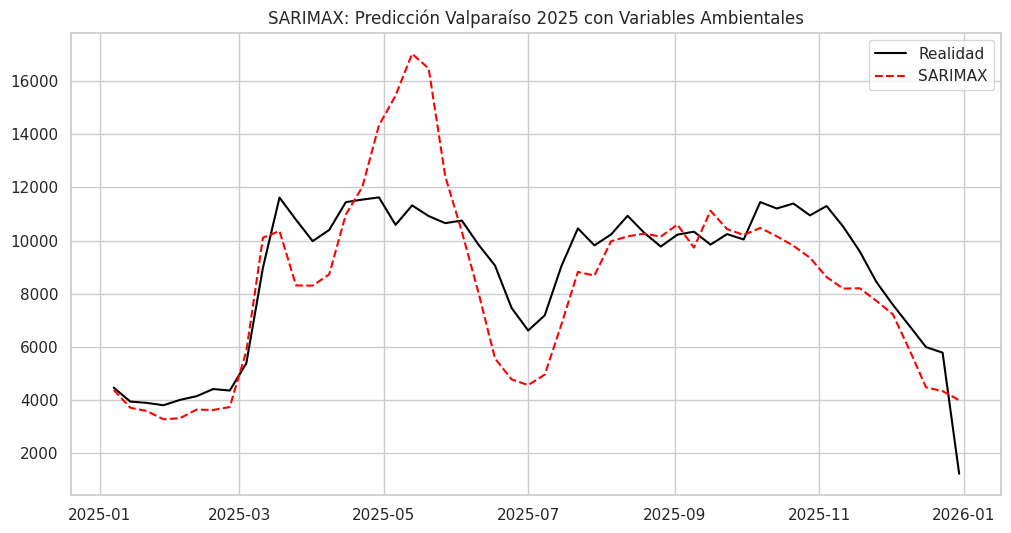

Métricas SARIMAX Valparaíso:
MAE:  1439.49
RMSE: 1927.85
MAPE: 19.81%


In [ ]:
# Dividimoss en Train y Test
train_s = df_sarima_valpo[df_sarima_valpo.index < '2025-01-01']
test_s = df_sarima_valpo[(df_sarima_valpo.index >= '2025-01-01') & (df_sarima_valpo['Atenciones_Urg'] > 100)]

# Definir Variables Externas
exog_train = train_s[['PM25_Lag1', 'Temp_Mediana_Semanal']]
exog_test = test_s[['PM25_Lag1', 'Temp_Mediana_Semanal']]

# Ajuste del Modelo SARIMAX
# (1,1,1)x(1,1,0,52) es una configuración inicial para realizar prueba
model = sm.tsa.statespace.SARIMAX(
    train_s['Atenciones_Urg'],
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = model.fit(disp=False)

# Predecimos
forecast_s = sarima_results.get_forecast(steps=len(test_s), exog=exog_test)
y_pred = forecast_s.predicted_mean

# Métricas
mae_s = mean_absolute_error(test_s['Atenciones_Urg'], y_pred)
mse_s = mean_squared_error(test_s['Atenciones_Urg'], y_pred)
rmse_s = np.sqrt(mse_s)
y_true = test_s['Atenciones_Urg']
mape_s = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

plt.figure(figsize=(12, 6))
plt.plot(test_s.index, test_s['Atenciones_Urg'], label='Realidad', color='black')
plt.plot(test_s.index, y_pred, label=f'SARIMAX', color='red', linestyle='--')
plt.title('SARIMAX: Predicción Valparaíso 2025 con Variables Ambientales')
plt.legend()
plt.show()

print(f"Métricas SARIMAX Valparaíso:")
print(f"MAE:  {mae_s:.2f}")
print(f"RMSE: {rmse_s:.2f}")
print(f"MAPE: {mape_s:.2f}%")

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.4 MB/s eta 0:00:00


In [ ]:

import pmdarima as pm

#Obtenemos los mejores parámetros para SARIMAX
stepwise_fit = pm.auto_arima(
   train_s['Atenciones_Urg'],
   exogenous=exog_train,
   start_p=0, start_q=0,
   max_p=2, max_q=2,
   m=52,
   seasonal=True,
   d=1, D=1,
   trace=True,
   error_action='ignore',
  stepwise=True,
   n_fits=10
)

print("\n--- MEJORES PARÁMETROS ENCONTRADOS ---")

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[52]             : AIC=inf, Time=51.36 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=2662.395, Time=1.05 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=2651.482, Time=4.89 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=2649.906, Time=8.21 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=2657.775, Time=0.51 sec
 ARIMA(0,1,1)(1,1,1)[52]             : AIC=inf, Time=26.67 sec
 ARIMA(0,1,1)(0,1,2)[52]             : AIC=inf, Time=46.98 sec
 ARIMA(0,1,1)(1,1,0)[52]             : AIC=2652.692, Time=7.47 sec
 ARIMA(0,1,1)(1,1,2)[52]             : AIC=inf, Time=98.85 sec
 ARIMA(0,1,0)(0,1,1)[52]             : AIC=2658.002, Time=4.75 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=2650.606, Time=9.74 sec
 ARIMA(0,1,2)(0,1,1)[52]             : AIC=2649.830, Time=14.92 sec
 ARIMA(0,1,2)(0,1,0)[52]             : AIC=2658.032, Time=0.78 sec
 ARIMA(0,1,2)(1,1,1)[52]             : AIC=inf, Time=29.14 sec
 ARIMA(0,1,2)(0,1,2)[52]             :

Se realizo la obtención del MAE de Sarimax con los p,q,d obtenidos con autoarima, y estos no tuvieron mejores resultados de MAE que los obtenidos manualmente

In [ ]:
#PRUEBA DE SARIMAX CON TODAS LAS REGIONES

resultados_sarimax = []
regiones_top10 = df_top10['RegionNombre'].unique()

for reg in regiones_top10:
    print(f"--- Procesando: {reg} ---")

    df_r = df_top10[df_top10['RegionNombre'] == reg].copy()
    df_r = df_r[['Semana', 'Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']].set_index('Semana')

    #División Train/Test
    train = df_r[df_r.index < '2025-01-01']
    test = df_r[(df_r.index >= '2025-01-01') & (df_r['Atenciones_Urg'] > 100)]

    #variables exógenas
    exog_train = train[['PM25_Lag1', 'Temp_Mediana_Semanal']]
    exog_test = test[['PM25_Lag1', 'Temp_Mediana_Semanal']]
    y_true = test['Atenciones_Urg']

    try:
        #Conf. Sarimasx (1,1,1)x(1,1,0,52)
        model = sm.tsa.statespace.SARIMAX(
            train['Atenciones_Urg'],
            exog=exog_train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 0, 52),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results = model.fit(disp=False)

        #pedecimos
        pred = results.get_forecast(steps=len(test), exog=exog_test).predicted_mean

        # calculamos las metricas
        mae = mean_absolute_error(y_true, pred)
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        mape = np.mean(np.abs((y_true - pred) / y_true)) * 100

    except Exception as e:
        print(f"Error en región {reg}: {e}")
        mae = rmse = mape = np.nan

    #metricas
    resultados_sarimax.append({
        'Región': reg,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    })

#df con resultados finales
df_final_sarimax = pd.DataFrame(resultados_sarimax)

pd.options.display.float_format = '{:.2f}'.format
print("\n--- RESULTADOS FINALES SARIMAX POR REGIÓ---")
print(df_final_sarimax)

--- Procesando: RM ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


--- Procesando: Aysén ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


--- Procesando: Araucanía ---


...

--- Procesando: O'Higgins ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


--- Procesando: Maule ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)



--- RESULTADOS FINALES SARIMAX POR REGIÓN (TEST 2025) ---
       Región     MAE    RMSE  MAPE (%)
0          RM 5577.92 6976.41     20.66
1       Aysén  164.74  228.58     20.65
2   Araucanía 1615.96 1964.21     44.22
3   Los Lagos 1037.27 1343.72     23.27
4    Los Ríos  444.88  634.66     21.02
5  Valparaíso 1439.49 1927.85     19.81
6       Ñuble  501.67  675.80     23.63
7     Bío-Bío 1731.86 2186.01     21.04
8   O'Higgins  962.94 1207.83     21.52
9       Maule 1427.94 1768.39     17.69


In [ ]:
#PRUEBA DE HOLT WINTERS CON LA REGIÓN DE VALPO

reg_v = "Valparaíso"
df_v = df_top10[df_top10['RegionNombre'] == reg_v].copy()
df_v = df_v[['Semana', 'Atenciones_Urg']].set_index('Semana')

train_v = df_v[df_v.index < '2025-01-01']
test_v = df_v[(df_v.index >= '2025-01-01') & (df_v['Atenciones_Urg'] > 100)]

train_v.index = pd.DatetimeIndex(train_v.index).to_period('W').to_timestamp() #ajsutamos frec. semanal

# Modelo Holt-Wintersa
model_hw_v = ExponentialSmoothing(
    train_v['Atenciones_Urg'],
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    initialization_method="estimated"
).fit()

pred_hw_v = model_hw_v.forecast(len(test_v))

# MÉTRICAS
y_true_v = test_v['Atenciones_Urg']
mae_hw_v = mean_absolute_error(y_true_v, pred_hw_v)
rmse_hw_v = np.sqrt(mean_squared_error(y_true_v, pred_hw_v))
mape_hw_v = np.mean(np.abs((y_true_v - pred_hw_v) / y_true_v)) * 100

print(f"Métricas HOLT WINTERS Valparaíso:")
print(f"MAE:  {mae_hw_v:.2f}")
print(f"RMSE: {rmse_hw_v:.2f}")
print(f"MAPE: {mape_hw_v:.2f}%")

Métricas HOLT WINTERS Valparaíso:
MAE:  1085.89
RMSE: 1550.55
MAPE: nan%


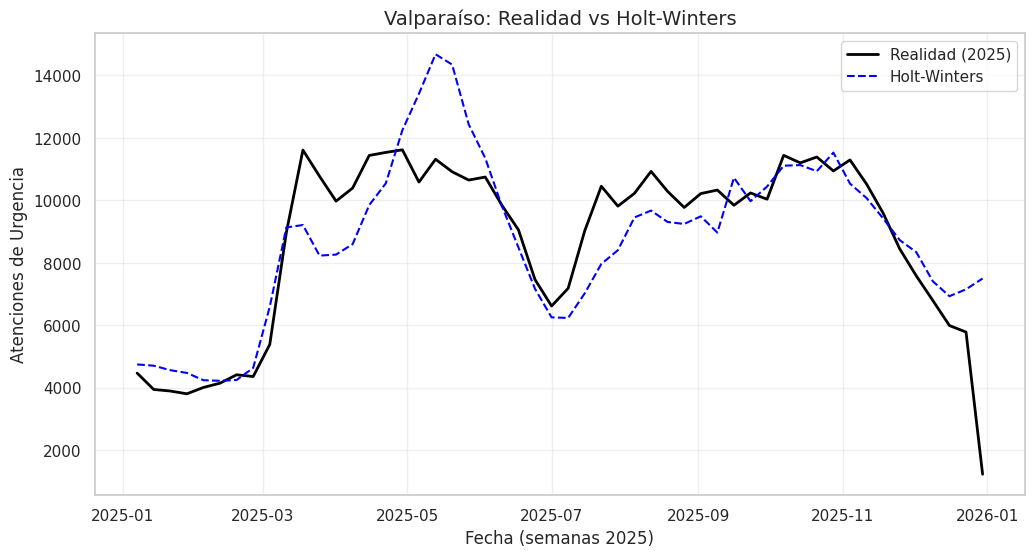

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test_v.index, test_v['Atenciones_Urg'], label='Realidad (2025)', color='black', linewidth=2)
plt.plot(test_v.index, pred_hw_v, label=f'Holt-Winters', color='blue', linestyle='--')

plt.title("Valparaíso: Realidad vs Holt-Winters", fontsize=14)
plt.ylabel("Atenciones de Urgencia")
plt.xlabel("Fecha (semanas 2025)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#realizamos holt winters para todas las regiones

resultados_hw = []


print(f"{'Región':<30} | {'MAE':<10} | {'RMSE':<10} | {'MAPE (%)':<10}")
print("-" * 70)

for reg in regiones_top10:
    try:
        df_r = df_top10[df_top10['RegionNombre'] == reg].copy()
        df_r = df_r[['Semana', 'Atenciones_Urg']].set_index('Semana').asfreq('W-TUE')

        train = df_r[df_r.index < '2025-01-01']
        test = df_r[(df_r.index >= '2025-01-01') & (df_r['Atenciones_Urg'] > 100)]

        if len(test) == 0:
            continue

        model_hw = ExponentialSmoothing(
            train['Atenciones_Urg'],
            trend='add',
            seasonal='add',
            seasonal_periods=52
        ).fit()

        y_true_hw = test['Atenciones_Urg'].values
        pred_hw = model_hw.forecast(len(test))
        mae_hw = mean_absolute_error(test['Atenciones_Urg'], pred_hw)
        rmse_hw = np.sqrt(mean_squared_error(y_true_hw, pred_hw))
        mape_hw = np.mean(np.abs((y_true_hw - pred_hw) / y_true_hw)) * 100

        print(f"{reg[:30]:<30} | {mae_hw:>10.2f} | {rmse_hw:>10.2f} | {mape_hw:>10.2f}%")

        resultados_hw.append({
            'Región': reg,
            'MAE_HW': mae_hw,
            'RMSE_HW': rmse_hw,
            'MAPE_HW': mape_hw
        })

    except Exception as e:
        # En caso de error, guardamos como None para no romper el loop
        resultados_hw.append({
            'Región': reg,
            'MAE_HW': None,
            'RMSE_HW': None,
            'MAPE_HW': None
        })
        print(f"Error en {reg}: {str(e)[:50]}...")

df_hw_final = pd.DataFrame(resultados_hw)

Región                         | MAE        | RMSE       | MAPE (%)  
----------------------------------------------------------------------
RM                             |    8657.24 |   10020.25 |      30.41%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Aysén                          |     165.02 |     225.95 |      20.23%
Araucanía                      |    1315.68 |    1578.44 |      37.03%
Los Lagos                      |    1284.02 |    1682.11 |      36.89%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Los Ríos                       |     455.19 |     564.86 |      24.63%
Valparaíso                     |    1085.89 |    1550.55 |      20.62%
Ñuble                          |     680.03 |     772.10 |      26.46%
Bío-Bío                        |    2203.69 |    2386.30 |      26.67%
O'Higgins                      |    1323.55 |    1571.40 |      27.93%
Maule                          |    3550.10 |    4240.69 |      34.82%
